In [7]:
import uproot
import pandas as pd
import numpy as np
import awkward as ak
import os
import json
import ROOT

In [8]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.lines as lines
from matplotlib.collections import PatchCollection
plt.rcParams.update({'font.size': 15})

In [9]:
os.environ['ttH_yy_DIR'] = '/eos/user/e/elmazzeo/ttH@FCC-hh/results/2025-05-05'

In [10]:
basedir = os.path.join(os.environ.get('ttH_yy_DIR'), 'final')
outdir = os.path.join(os.environ.get('ttH_yy_DIR'), 'plots')

color_sequence = ["#3f90da","#ffa90e","#bd1f01","#94a4a2","#832db6","#a96b59","#e76300","#b9ac70","#717581","#92dadd"]

process = {
    'ttZee' : { 
        'sample_list' : ['mgp8_pp_ttz01j_5f_84TeV_zee'], 
               'label' : r'$ttZ$ $\rightarrow$ ee', 'kfactor' : 1.,
        'color' : color_sequence[0]},
    'WZjets' : { 
        'sample_list' : ['mgp8_pp_WZjj_HF_5f_84TeV_zeewlep'], 
               'label' : 'WZ+jets', 'kfactor' : 1.,
        'color' : color_sequence[1]},
    'ZZjets' : { 'sample_list' : ['mgp8_pp_ZZjj_HF_5f_84TeV_zzlep'], 
               'label' : 'ZZ+jets', 'kfactor' : 1.,
        'color' : color_sequence[2]},
    'tZj' : { 'sample_list' : ['mgp8_pp_tZj_5f_84TeV_zeewlep'], 
               'label' : 'tZq', 'kfactor' : 1.,
        'color' : color_sequence[3]},
    'tWZj' : { 'sample_list' : ['mgp8_pp_tWZj_5f_84TeV_zee'], 
               'label' : 'tWZ+jets', 'kfactor' : 1.,
        'color' : color_sequence[4]},
}

selection = {
#           "nocuts" : "All events", # all events
#           "electrons": "$\geq$ 2 electrons",
#           "electrons_charge" :  "2 opposite charge $e$",
#           "electrons_mee_window": "$Z\to ee$ cand.",
           "preselection": "$Z\to ee$ cand. + $\geq$ 2 $b$-jets",
#           "trilep_channel": "Trilepton channel",
#           "tetralep_channel" : "Tetralep. channel",
#           "lep_channel" : "Combined"
}

variables = ['weight']

process_infos = ["/eos/experiment/fcc/hh/utils/FCCDicts/FCChh_procDict_fcc_v07_II.json"]

lumi = 3e7 # 3 * 10^7 pb-1 = 3 ab-1

In [11]:
def error_boxes (ax,x,y,x_err,y_err,fc='lightgrey',ec='None',alpha=0.5, hatch=None):

    # Create list for all the error patches
    errorboxes = []

    # Loop over data points; create box from errors at each point
    for xc,yc,xe,ye in zip(x,y,x_err.T,y_err.T):
        rect = patches.Rectangle((xc-xe,yc-ye),2*xe,2*ye)
        errorboxes.append(rect)

    # Create patch collection with specified colour/alpha
    pc = PatchCollection(errorboxes,facecolor=fc,alpha=alpha,edgecolor=ec, hatch=hatch)

    # Add collection to axes
    ax.add_collection(pc)

In [12]:
process_dicts = []
for inputname in process_infos :
    with open(inputname, 'r') as f :
        process_dicts.append(json.load(f))

In [13]:
from importlib import import_module
import sys
sys.path.insert(1, "../")

In [14]:
analysis_final = import_module("analysis_final")
variables_dict = analysis_final.histoList
variables_list = ['weight', 
                  'pT_e1', 'eta_e1', 'phi_e1', "E_e1", "charge_e1",
                  'pT_e2', 'eta_e2', 'phi_e2', "E_e2", "charge_e2",
                  "m_ee", "pT_ee",
                  "pT_l3", 'eta_l3', 'phi_l3', "E_l3", "charge_l3", "pdgID_l3",
                  "pT_l4", 'eta_l4', 'phi_l4', "E_l4", "charge_l4", "pdgID_l4",
                  "pT_b1", "eta_b1", "phi_b1", "E_b1", 
                  "pT_b2", "eta_b2", "phi_b2", "E_b2", 
                  "n_bjets",
                  "pT_top_had_jet2", "pT_top_had_jet2", "phi_top_had_jet2", "E_top_had_jet2",
                  "pT_top_had_jet3", "pT_top_had_jet3", "phi_top_had_jet3", "E_top_had_jet3",
                  "m_w_had", "pT_w_had", "eta_w_had", "phi_w_had", 
                  "n_jets", "topness", "HT", "MET", "MET_phi"
                 ]

In [15]:
df = {}
sow = {}

In [16]:
for p in process.keys() :
    if p in list(df.keys()) :
        pass
    else :
        df[p] = {}
    print(p)
    for s in selection.keys() :
        if s in list(df[p].keys()) :
            pass
        else :
            print("\t\t"+s)
            df1 = []
            sow[p] = []
            for sample in process[p]['sample_list'] :
                inputfile = os.path.join(basedir, sample+"_"+s+".root")
                # get sum of weights
                f = ROOT.TFile.Open(inputfile)
                sow[p].append(f.Get("SumOfWeights").GetVal())
                f.Close()
                # get sample dict
                for d in process_dicts :
                    if sample in list(d.keys()) :
                        process_dict = d.copy()
                        break
                # get sample
                with uproot.open(inputfile) as f :
                    df1.append(ak.to_dataframe(f['events'].arrays(expressions=variables_list, library='ak')))
                    df1[-1]["weight"] = df1[-1]["weight"]/sow[p][-1]#*process_dict[sample]['crossSection']*process_dict[sample]['kfactor']*process_dict[sample]['matchingEfficiency']
            df[p][s] = pd.concat(df1, copy=True, ignore_index=True)
            if "charge_e1" in variables_list and "charge_e2" in variables_list :
                df[p][s]["ee_charge"] = df[p][s]["charge_e1"]*df[p][s]["charge_e2"]

ttZee
		preselection
WZjets
		preselection
ZZjets
		preselection
tZj
		preselection
tWZj
		preselection


In [17]:
#sel_key= 'nocuts'
#sel_label = "All events"
sel_key = "preselection"
sel_label = r"$Z\to ee$ cand. + $\geq$ 2 $b$-jets"
to_plot = [ "pT_top_had_jet2", "pT_top_had_jet2", "phi_top_had_jet2", "E_top_had_jet2",
            "pT_top_had_jet3", "pT_top_had_jet3", "phi_top_had_jet3", "E_top_had_jet3",
            "m_w_had", "pT_w_had", "eta_w_had", "phi_w_had", 
            "n_jets", "topness", "HT", "MET", "MET_phi"]

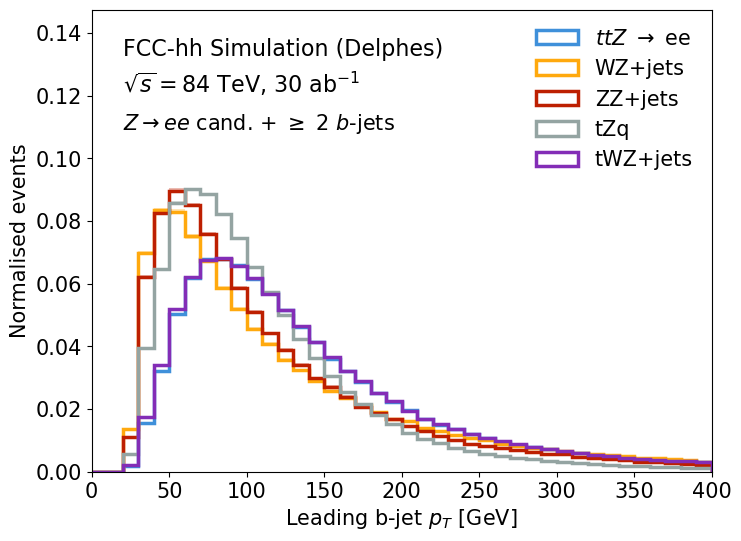

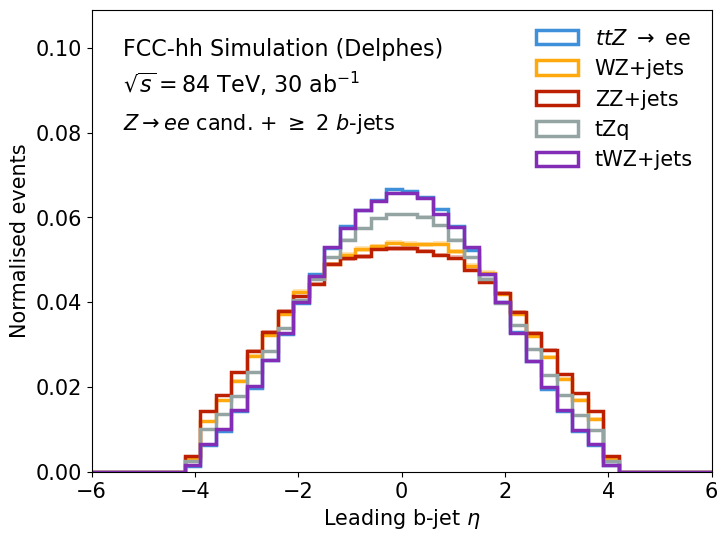

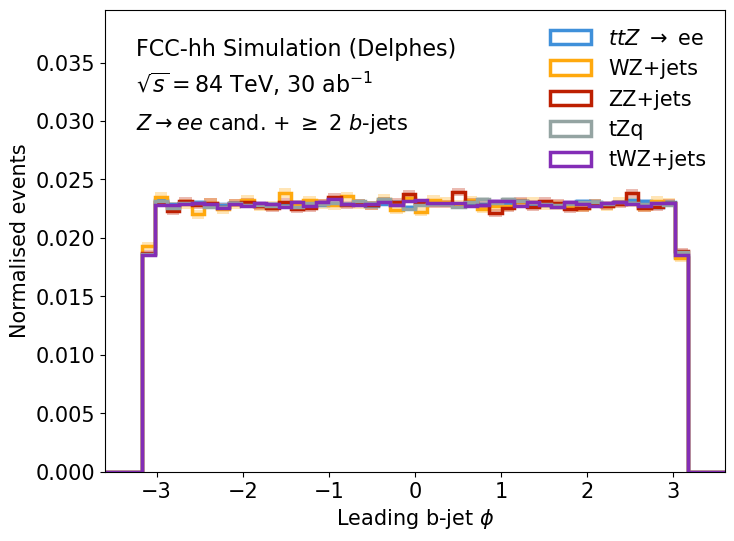

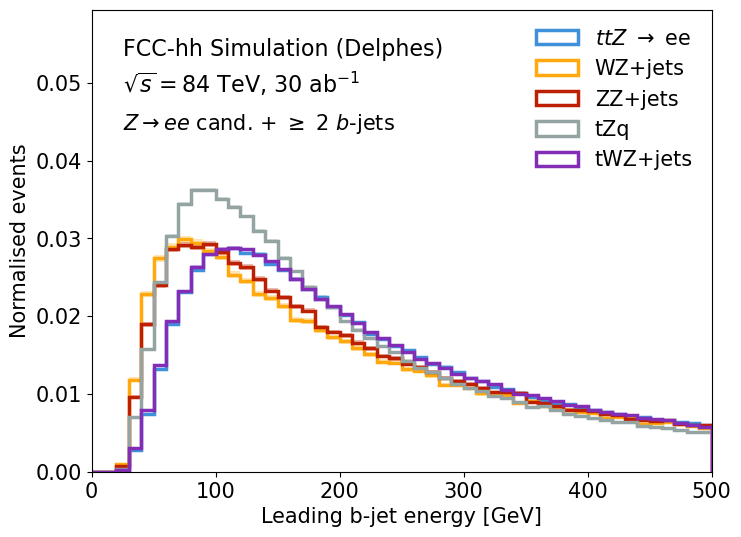

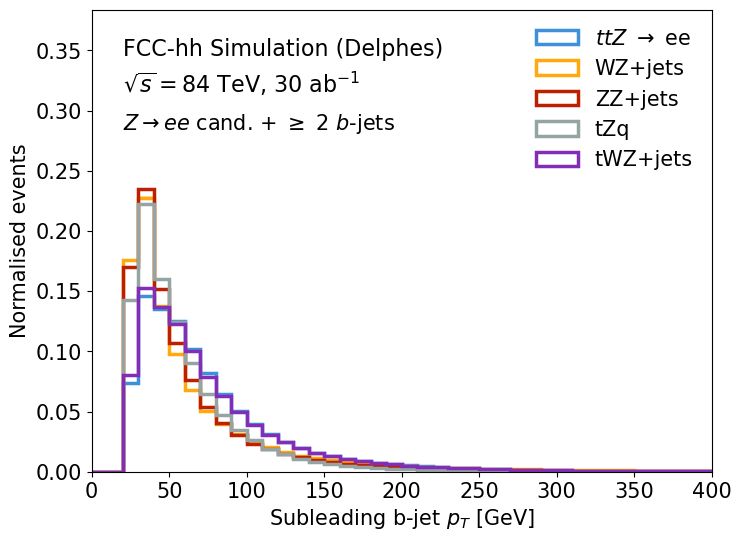

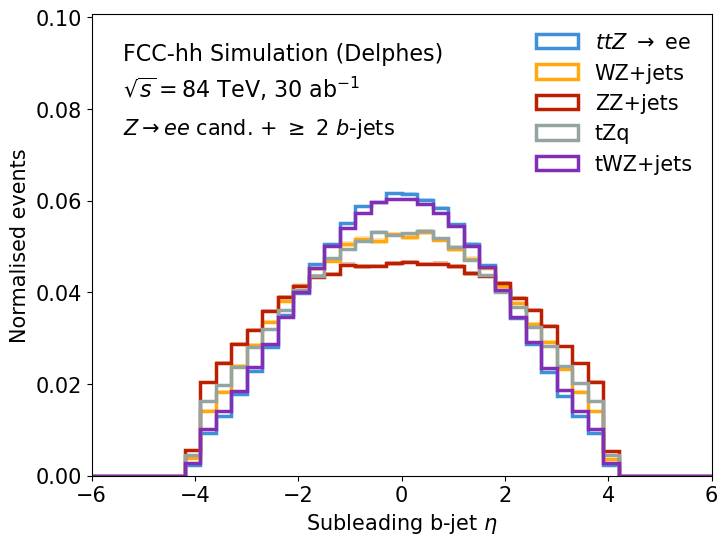

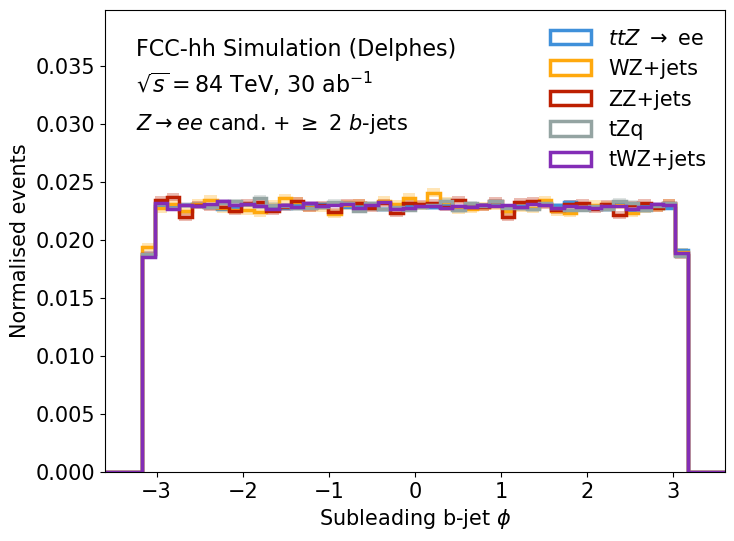

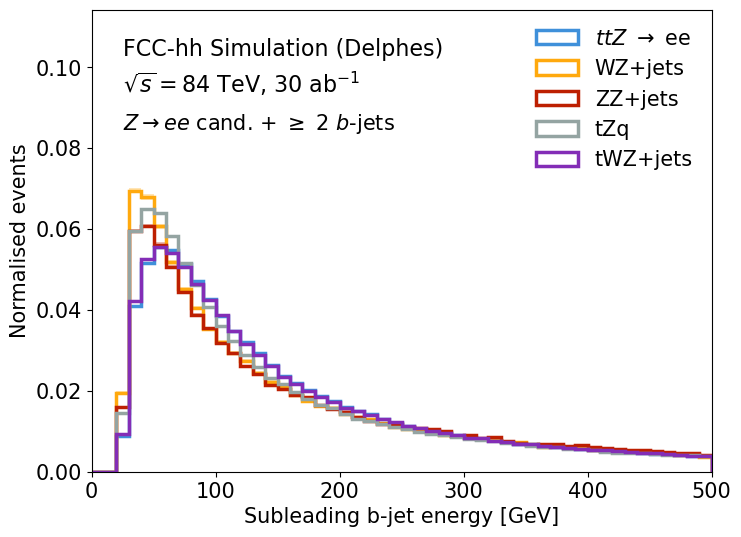

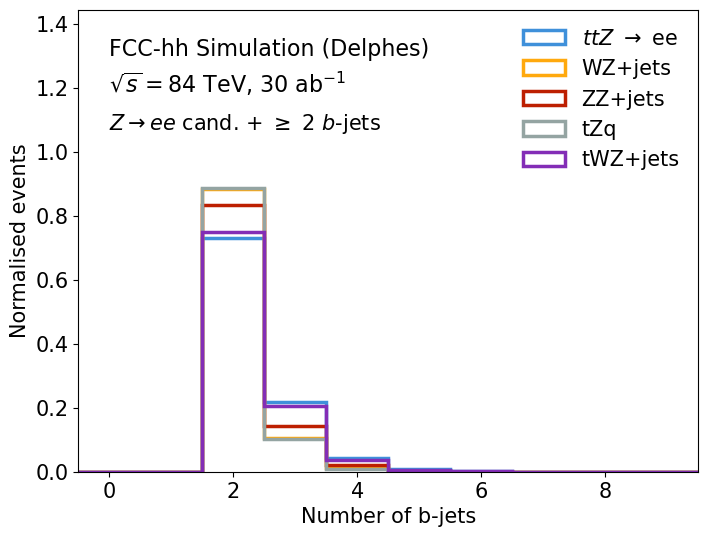

In [24]:
for variable in to_plot :
    infos = variables_dict[variable].copy()
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(8,6)
    )
    for p in process.keys() :
        bin_values, bin_edges, _ = ax.hist(df[p][sel_key][variable], 
                                           weights=df[p][sel_key]["weight"]/df[p][sel_key]["weight"].sum(),
                                           bins=infos["bin"], range=(infos["xmin"], infos["xmax"]),
                                           histtype='step', linewidth=2.5, color=process[p]["color"],
                                           label=process[p]["label"])
        x = 0.5*(bin_edges[1:]+bin_edges[:-1])
        xerr = 0.5*(bin_edges[1:]-bin_edges[:-1])
        bin_unc, _ = np.histogram(df[p][sel_key][variable], 
                                  weights=(df[p][sel_key]["weight"]/df[p][sel_key]["weight"].sum())**2,
                                  bins=infos["bin"], range=(infos["xmin"], infos["xmax"]))
        bin_unc = np.sqrt(bin_unc)
        error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc=process[p]["color"])

    #ax.axvline(0.1, ymin=0, ymax=0.7, color='darkgrey', ls='--', lw=2.)
    
    ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.82, r"$\sqrt{s}=84$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.74, sel_label, transform=ax.transAxes, fontsize=15)

    ax.legend(loc='upper right', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))
    xlabel = infos["latex"] if "latex" in list(infos.keys()) else infos["title"]
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Normalised events')

    #ax.set_yscale("log")
    ax.set_xlim(infos["xmin"], infos["xmax"])
    ymin,ymax = ax.get_ylim() 
    ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.55)
    
    plotname = infos["name"]+"_ttZee_analysis_validation_"+sel_key
    plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
    plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
    plt.show()